# Walmart M5 Model Evaluation & Backtesting

## Business Objective

Notebook 04 trained and selected a **Poisson Histogram Gradient Boosting** demand model.

The saved Notebook 04 results showed:

- validation RMSE: approximately **1.831**
- validation MAE: approximately **1.073**
- test RMSE: approximately **2.206**
- test MAE: approximately **1.252**
- test WAPE: approximately **80.7%**
- the model outperformed the `lag_7` and `lag_28` validation baselines
- the strongest permutation-importance features were `rolling_mean_28`, `zero_sales_share_28`, and `rolling_mean_7`

This notebook performs deeper evaluation before the forecasting system is allowed to feed a dynamic-pricing engine.

We will examine:

- test-set performance versus naive baselines
- forecast bias
- daily aggregate behavior
- error by test day
- zero-demand versus positive-demand behavior
- error by product and demand level
- worst misses
- calibration by predicted-demand bucket
- rolling-origin backtesting
- stability across backtest windows
- final model acceptance criteria

> **Important evaluation note:** the current feature table contains lag and rolling features calculated using observed history up to each row. Therefore the current Notebook 04 predictions represent a **daily-updated forecasting setting** rather than a strict one-shot 28-day forecast made entirely at the beginning of the horizon. This notebook evaluates that setting honestly and documents what must change before true production multi-step forecasting.

## 1. Import Libraries

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")

## 2. Define Project Paths

Notebook 04 saved:

- the feature-engineered dataset
- model metadata
- test predictions

This notebook reads those outputs directly so we evaluate exactly what Notebook 04 produced.

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
MODELING_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
EVALUATION_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "evaluation"

FEATURE_FILE = (
    PROCESSED_DIR
    / "features_CA_1_200_items.csv"
)

METADATA_FILE = (
    MODEL_DIR
    / "demand_forecast_model_metadata.json"
)

TEST_PREDICTIONS_FILE = (
    MODELING_OUTPUT_DIR
    / "test_predictions.csv"
)

EVALUATION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BACKTEST_RESULTS_FILE = (
    EVALUATION_OUTPUT_DIR
    / "rolling_backtest_results.csv"
)

PRODUCT_ERROR_FILE = (
    EVALUATION_OUTPUT_DIR
    / "product_error_summary.csv"
)

## 3. Load Feature Data, Metadata, and Test Predictions

In [3]:
features = pd.read_csv(
    FEATURE_FILE,
    parse_dates=["date"],
)

test_predictions = pd.read_csv(
    TEST_PREDICTIONS_FILE,
    parse_dates=["date"],
)

with open(
    METADATA_FILE,
    "r",
    encoding="utf-8",
) as file:
    metadata = json.load(file)

print("Feature data:", features.shape)
print("Test predictions:", test_predictions.shape)
print("Selected model:", metadata["selected_model"])
print("Test period:", metadata["test_start_date"], "to", metadata["test_end_date"])

test_predictions.head()

Feature data: (382600, 47)
Test predictions: (5600, 7)
Selected model: poisson_hist_gradient_boosting
Test period: 2016-04-25 to 2016-05-22


,date,item_id,store_id,units_sold,prediction,residual,absolute_error
0,2016-04-25,FOODS_1_001,CA_1,2,0.811261,1.188739,1.188739
1,2016-04-25,FOODS_1_002,CA_1,0,0.450272,-0.450272,0.450272
2,2016-04-25,FOODS_1_003,CA_1,3,0.702118,2.297882,2.297882
3,2016-04-25,FOODS_1_004,CA_1,0,0.056105,-0.056105,0.056105
4,2016-04-25,FOODS_1_005,CA_1,1,1.291144,-0.291144,0.291144


## 4. Define Evaluation Metrics

The same core metrics from Notebook 04 are reused so comparisons remain consistent.

In [4]:
def evaluate_predictions(
    y_true,
    y_pred,
):
    y_true = np.asarray(y_true)
    y_pred = np.clip(
        np.asarray(y_pred),
        0,
        None,
    )

    mae = mean_absolute_error(
        y_true,
        y_pred,
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred,
        )
    )

    denominator = np.abs(y_true).sum()

    wape = (
        np.abs(y_true - y_pred).sum()
        / denominator
        if denominator != 0
        else np.nan
    )

    rmsle = np.sqrt(
        mean_squared_log_error(
            y_true,
            y_pred,
        )
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape,
        "RMSLE": rmsle,
    }

## 5. Reconfirm Final Test Performance

This should reproduce the Notebook 04 test metrics.

In [5]:
model_test_metrics = evaluate_predictions(
    test_predictions["units_sold"],
    test_predictions["prediction"],
)

pd.DataFrame(
    [
        {
            "model": metadata["selected_model"],
            **model_test_metrics,
        }
    ]
)

,model,MAE,RMSE,WAPE,RMSLE
0,poisson_hist_gradient_boosting,1.252022,2.206089,0.807384,0.606301


## 6. Test-Set Naive Baselines

Notebook 04 selected the ML model using validation data. Now compare the selected model with the same naive rules on the **final test period**.

- `lag_7`: same demand as one week earlier
- `lag_28`: same demand as four weeks earlier

In [6]:
test_start = test_predictions["date"].min()
test_end = test_predictions["date"].max()

test_features = features.loc[
    (features["date"] >= test_start)
    & (features["date"] <= test_end)
].copy()

baseline_test_results = []

for baseline_name in [
    "lag_7",
    "lag_28",
]:
    metrics = evaluate_predictions(
        test_features["units_sold"],
        test_features[baseline_name],
    )

    baseline_test_results.append({
        "model": baseline_name,
        **metrics,
    })

baseline_test_results.append({
    "model": metadata["selected_model"],
    **model_test_metrics,
})

test_model_comparison = (
    pd.DataFrame(baseline_test_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

test_model_comparison

,model,MAE,RMSE,WAPE,RMSLE
0,poisson_hist_gradient_boosting,1.252022,2.206089,0.807384,0.606301
1,lag_28,1.583214,2.858821,1.020958,0.822423
2,lag_7,1.629643,2.923672,1.050898,0.811674


### Improvement Over the Weekly Naive Baseline

Measure how much RMSE and MAE improve relative to `lag_7`.

In [7]:
lag7_row = test_model_comparison.loc[
    test_model_comparison["model"] == "lag_7"
].iloc[0]

ml_row = test_model_comparison.loc[
    test_model_comparison["model"] == metadata["selected_model"]
].iloc[0]

rmse_improvement = (
    1
    - ml_row["RMSE"]
    / lag7_row["RMSE"]
)

mae_improvement = (
    1
    - ml_row["MAE"]
    / lag7_row["MAE"]
)

print(
    "RMSE improvement vs lag_7:",
    f"{rmse_improvement:.2%}",
)

print(
    "MAE improvement vs lag_7:",
    f"{mae_improvement:.2%}",
)

RMSE improvement vs lag_7: 24.54%
MAE improvement vs lag_7: 23.17%


## 7. Forecast Bias

Bias tells us whether the model systematically predicts too high or too low.

Residual:

`actual - prediction`

- positive mean residual → underprediction
- negative mean residual → overprediction

In [8]:
test_eval = test_predictions.copy()

if "residual" not in test_eval.columns:
    test_eval["residual"] = (
        test_eval["units_sold"]
        - test_eval["prediction"]
    )

if "absolute_error" not in test_eval.columns:
    test_eval["absolute_error"] = (
        test_eval["residual"].abs()
    )

mean_residual = (
    test_eval["residual"].mean()
)

total_actual = (
    test_eval["units_sold"].sum()
)

total_predicted = (
    test_eval["prediction"].sum()
)

total_bias = (
    total_predicted
    - total_actual
)

bias_pct = (
    total_bias
    / total_actual
    if total_actual != 0
    else np.nan
)

print("Mean residual:", mean_residual)
print("Total actual units:", total_actual)
print("Total predicted units:", total_predicted)
print("Total prediction bias:", total_bias)
print("Bias percent:", f"{bias_pct:.2%}")

Mean residual: -0.018008189106952812
Total actual units: 8684
Total predicted units: 8784.845858998937
Total prediction bias: 100.84585899893682
Bias percent: 1.16%


## 8. Daily Aggregate Forecast Accuracy

Aggregate all 200 products to the daily level.

This shows whether product-level errors cancel out or accumulate into a meaningful store-level forecasting error.

In [9]:
daily_eval = (
    test_eval
    .groupby(
        "date",
        as_index=False,
    )
    .agg(
        actual_units=("units_sold", "sum"),
        predicted_units=("prediction", "sum"),
    )
)

daily_eval["error"] = (
    daily_eval["actual_units"]
    - daily_eval["predicted_units"]
)

daily_eval["absolute_error"] = (
    daily_eval["error"].abs()
)

daily_eval

,date,actual_units,predicted_units,error,absolute_error
0,2016-04-25,268,255.558909,12.441091,12.441091
1,2016-04-26,238,242.583675,-4.583675,4.583675
2,2016-04-27,238,251.852760,-13.852760,13.852760
3,2016-04-28,289,277.036614,11.963386,11.963386
4,2016-04-29,351,334.825020,16.174980,16.174980
5,2016-04-30,420,390.623680,29.376320,29.376320
6,2016-05-01,361,337.506319,23.493681,23.493681
7,2016-05-02,239,290.328457,-51.328457,51.328457
8,2016-05-03,300,279.584186,20.415814,20.415814
9,2016-05-04,240,282.435831,-42.435831,42.435831


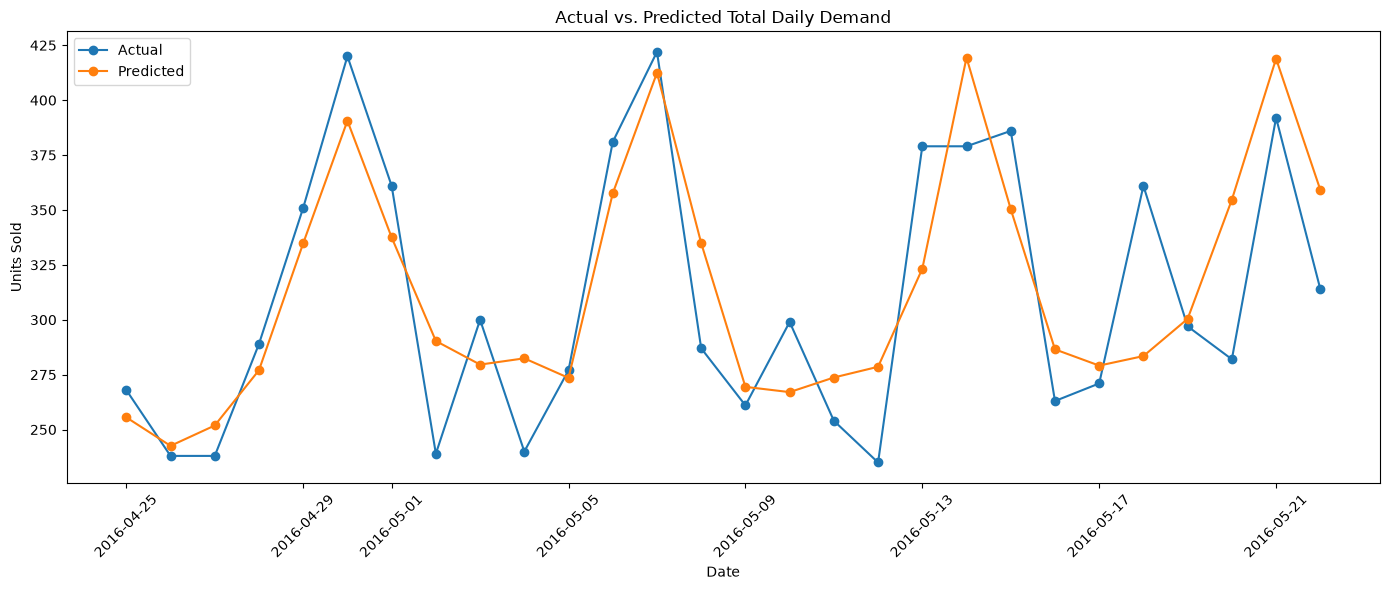

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_eval["date"],
    daily_eval["actual_units"],
    marker="o",
    label="Actual",
)

ax.plot(
    daily_eval["date"],
    daily_eval["predicted_units"],
    marker="o",
    label="Predicted",
)

ax.set_title(
    "Actual vs. Predicted Total Daily Demand"
)
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Error by Test Day

The current evaluation is a **daily-updated forecast setting** because lag/rolling features use observed history up to each row.

Therefore the variable below is named `test_day`, not true `forecast_horizon`.

It tells us whether errors became larger or smaller across the 28-day holdout period.

In [11]:
ordered_test_dates = (
    pd.Series(
        sorted(
            test_eval["date"].unique()
        )
    )
)

test_day_map = {
    date: index + 1
    for index, date
    in enumerate(ordered_test_dates)
}

test_eval["test_day"] = (
    test_eval["date"]
    .map(test_day_map)
)

test_day_error = (
    test_eval
    .groupby(
        "test_day",
        as_index=False,
    )
    .agg(
        date=("date", "first"),
        actual_units=("units_sold", "sum"),
        predicted_units=("prediction", "sum"),
        mae=("absolute_error", "mean"),
        bias=("residual", "mean"),
    )
)

test_day_error

,test_day,date,actual_units,predicted_units,mae,bias
0,1,2016-04-25,268,255.558909,1.086252,0.062205
1,2,2016-04-26,238,242.583675,1.123694,-0.022918
2,3,2016-04-27,238,251.852760,1.030081,-0.069264
3,4,2016-04-28,289,277.036614,1.105607,0.059817
4,5,2016-04-29,351,334.825020,1.350603,0.080875
5,6,2016-04-30,420,390.623680,1.377872,0.146882
6,7,2016-05-01,361,337.506319,1.225385,0.117468
7,8,2016-05-02,239,290.328457,1.081765,-0.256642
8,9,2016-05-03,300,279.584186,1.130614,0.102079
9,10,2016-05-04,240,282.435831,1.103690,-0.212179


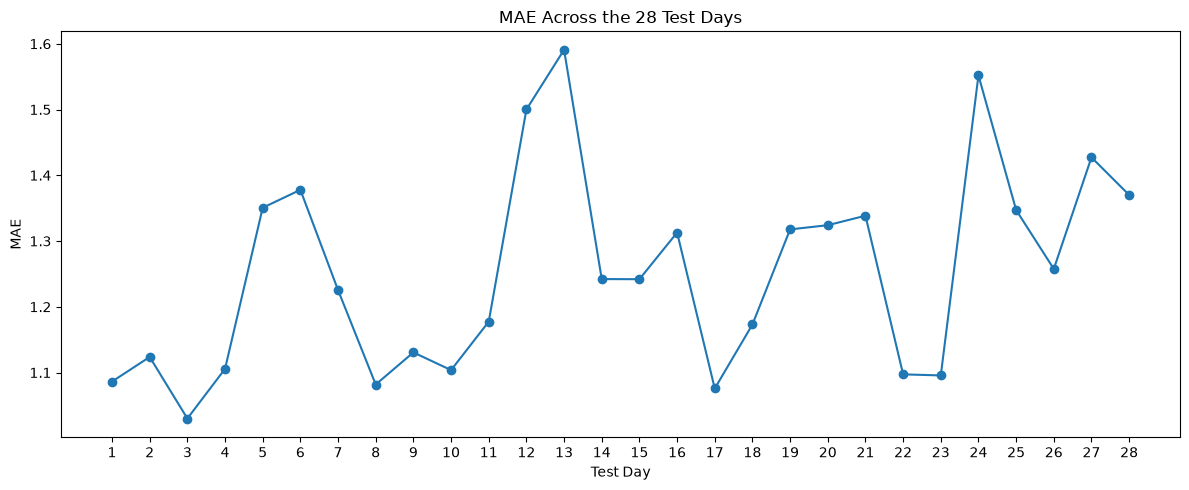

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    test_day_error["test_day"],
    test_day_error["mae"],
    marker="o",
)

ax.set_title("MAE Across the 28 Test Days")
ax.set_xlabel("Test Day")
ax.set_ylabel("MAE")
ax.set_xticks(range(1, 29))

plt.tight_layout()
plt.show()

## 10. Zero-Demand vs. Positive-Demand Performance

Notebook 02 found that product-store demand is highly intermittent.

Evaluate the model separately on:

- actual zero-demand rows
- actual positive-demand rows

In [13]:
test_eval["actual_demand_type"] = np.where(
    test_eval["units_sold"] == 0,
    "Zero demand",
    "Positive demand",
)

demand_type_summary = (
    test_eval
    .groupby(
        "actual_demand_type"
    )
    .apply(
        lambda group: pd.Series({
            "rows": len(group),
            "actual_units": group["units_sold"].sum(),
            "predicted_units": group["prediction"].sum(),
            "MAE": mean_absolute_error(
                group["units_sold"],
                group["prediction"],
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    group["units_sold"],
                    group["prediction"],
                )
            ),
        })
    )
    .reset_index()
)

demand_type_summary

,actual_demand_type,rows,actual_units,predicted_units,MAE,RMSE
0,Positive demand,3057.0,8684.0,6369.285427,1.503357,2.759908
1,Zero demand,2543.0,0.0,2415.560432,0.949886,1.249266


### False Positive Demand on Zero-Sales Rows

For rows where actual demand is zero, inspect how much positive demand the model tends to predict.

In [14]:
zero_rows = test_eval.loc[
    test_eval["units_sold"] == 0
].copy()

print(
    "Zero-demand rows:",
    f"{len(zero_rows):,}",
)

print(
    "Average prediction on zero-demand rows:",
    zero_rows["prediction"].mean(),
)

print(
    "Median prediction on zero-demand rows:",
    zero_rows["prediction"].median(),
)

print(
    "Share predicted above 1 unit:",
    f"{(zero_rows['prediction'] > 1).mean():.2%}",
)

Zero-demand rows: 2,543
Average prediction on zero-demand rows: 0.9498861314263463
Median prediction on zero-demand rows: 0.810321201384797
Share predicted above 1 unit: 35.43%


## 11. Product-Level Error Analysis

Identify which products are easiest and hardest to forecast.

In [15]:
product_error = (
    test_eval
    .groupby(
        "item_id",
        as_index=False,
    )
    .agg(
        actual_units=("units_sold", "sum"),
        predicted_units=("prediction", "sum"),
        mae=("absolute_error", "mean"),
        mean_bias=("residual", "mean"),
        max_absolute_error=("absolute_error", "max"),
    )
)

product_error["volume_error_pct"] = (
    (
        product_error["predicted_units"]
        - product_error["actual_units"]
    )
    / product_error["actual_units"].replace(0, np.nan)
)

product_error = product_error.sort_values(
    "mae",
    ascending=False,
)

product_error.head(20)

,item_id,actual_units,predicted_units,mae,mean_bias,max_absolute_error,volume_error_pct
17,FOODS_1_019,205,216.242763,5.939075,-0.401527,17.269022,0.054843
86,FOODS_1_088,112,47.986075,4.335535,2.286212,75.766550,-0.571553
84,FOODS_1_086,121,131.152087,4.169714,-0.362575,8.009355,0.083902
16,FOODS_1_018,243,262.046716,4.145152,-0.680240,10.971457,0.078382
53,FOODS_1_055,108,70.595827,4.050755,1.335863,25.247136,-0.346335
83,FOODS_1_085,184,222.399031,4.013459,-1.371394,12.351835,0.208690
97,FOODS_1_099,208,257.434513,3.747711,-1.765518,8.372436,0.237666
41,FOODS_1_043,220,190.790493,3.666530,1.043197,14.813471,-0.132770
44,FOODS_1_046,199,234.795631,3.644816,-1.278415,8.822936,0.179878
196,FOODS_1_200,207,247.527744,3.012837,-1.447419,8.773222,0.195786


In [16]:
product_error.to_csv(
    PRODUCT_ERROR_FILE,
    index=False,
)

print(
    "Saved:",
    PRODUCT_ERROR_FILE,
)

Saved: ..\outputs\evaluation\product_error_summary.csv


## 12. Demand-Level Error Analysis

Use average historical training demand to divide products into low, medium, and high-demand groups.

Notebook 04 showed the high-demand group had the largest MAE. This section reproduces and expands that comparison.

In [17]:
train_end_date = pd.to_datetime(
    metadata["train_end_date"]
)

historical_for_demand_groups = (
    features.loc[
        features["date"] <= train_end_date
    ]
)

training_item_demand = (
    historical_for_demand_groups
    .groupby(
        "item_id",
        as_index=False,
    )["units_sold"]
    .mean()
    .rename(
        columns={
            "units_sold":
            "average_training_demand"
        }
    )
)

demand_group_eval = test_eval.merge(
    training_item_demand,
    on="item_id",
    how="left",
    validate="many_to_one",
)

demand_group_eval["demand_group"] = pd.qcut(
    demand_group_eval[
        "average_training_demand"
    ],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High",
    ],
    duplicates="drop",
)

demand_group_summary = (
    demand_group_eval
    .groupby(
        "demand_group",
        observed=True,
    )
    .agg(
        rows=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        mean_bias=("residual", "mean"),
        actual_units=("units_sold", "sum"),
        predicted_units=("prediction", "sum"),
    )
    .reset_index()
)

demand_group_summary

,demand_group,rows,mae,mean_bias,actual_units,predicted_units
0,Low,1904,0.714640,-0.016267,1258,1288.971839
1,Medium,1848,1.115889,0.056323,2264,2159.915752
2,High,1848,1.941821,-0.094133,5162,5335.958268


## 13. Worst Individual Forecast Misses

Large misses matter operationally because they can create inventory shortages or excess stock.

Inspect the largest absolute errors.

In [18]:
worst_misses = (
    test_eval
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    [
        [
            "date",
            "item_id",
            "store_id",
            "units_sold",
            "prediction",
            "residual",
            "absolute_error",
        ]
    ]
    .head(30)
)

worst_misses

,date,item_id,store_id,units_sold,prediction,residual,absolute_error
4686,2016-05-18,FOODS_1_088,CA_1,77,1.233450,75.766550,75.766550
2253,2016-05-06,FOODS_1_055,CA_1,28,2.752864,25.247136,25.247136
781,2016-04-28,FOODS_1_185,CA_1,21,1.378477,19.621523,19.621523
3617,2016-05-13,FOODS_1_019,CA_1,21,3.730978,17.269022,17.269022
4253,2016-05-16,FOODS_1_055,CA_1,19,1.997690,17.002310,17.002310
5230,2016-05-21,FOODS_1_032,CA_1,21,4.186719,16.813281,16.813281
841,2016-04-29,FOODS_1_043,CA_1,19,4.186529,14.813471,14.813471
5213,2016-05-21,FOODS_1_015,CA_1,16,1.208585,14.791415,14.791415
2889,2016-05-09,FOODS_1_091,CA_1,16,1.665699,14.334301,14.334301
3665,2016-05-13,FOODS_1_067,CA_1,15,1.200806,13.799194,13.799194


## 14. Prediction Calibration by Forecast Level

Group predictions into five buckets and compare average predicted demand with average actual demand.

A well-calibrated model should produce similar actual and predicted averages within each bucket.

In [19]:
calibration = test_eval.copy()

calibration["prediction_bucket"] = pd.qcut(
    calibration["prediction"],
    q=5,
    duplicates="drop",
)

calibration_summary = (
    calibration
    .groupby(
        "prediction_bucket",
        observed=True,
    )
    .agg(
        rows=("prediction", "size"),
        average_prediction=("prediction", "mean"),
        average_actual=("units_sold", "mean"),
        mae=("absolute_error", "mean"),
    )
    .reset_index()
)

calibration_summary

,prediction_bucket,rows,average_prediction,average_actual,mae
0,"(0.015799999999999998, 0.6]",1120,0.327497,0.365179,0.527597
1,"(0.6, 0.907]",1120,0.768145,0.806250,0.861236
2,"(0.907, 1.293]",1120,1.090575,1.236607,1.149300
3,"(1.293, 1.971]",1120,1.584676,1.641964,1.373324
4,"(1.971, 16.61]",1120,4.072720,3.703571,2.348652


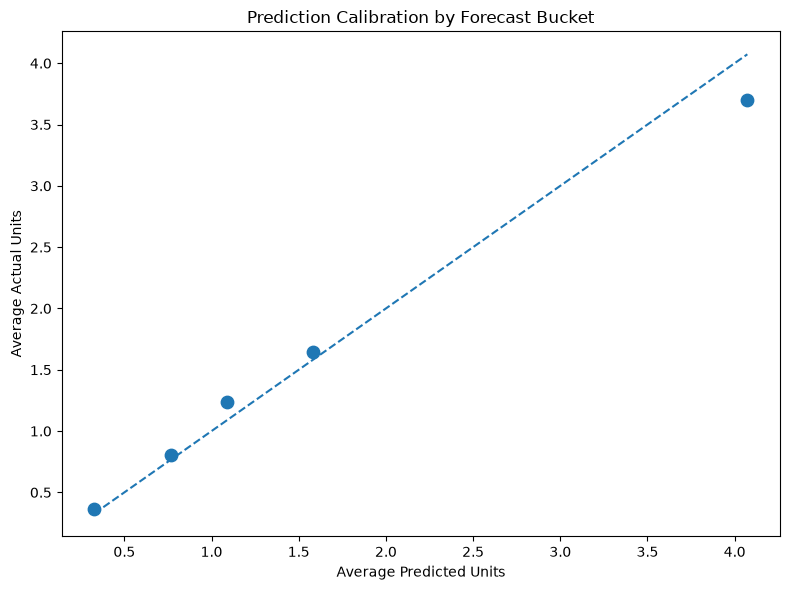

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    calibration_summary[
        "average_prediction"
    ],
    calibration_summary[
        "average_actual"
    ],
    s=80,
)

minimum = min(
    calibration_summary[
        "average_prediction"
    ].min(),
    calibration_summary[
        "average_actual"
    ].min(),
)

maximum = max(
    calibration_summary[
        "average_prediction"
    ].max(),
    calibration_summary[
        "average_actual"
    ].max(),
)

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
)

ax.set_title(
    "Prediction Calibration by Forecast Bucket"
)
ax.set_xlabel("Average Predicted Units")
ax.set_ylabel("Average Actual Units")

plt.tight_layout()
plt.show()

# Rolling-Origin Backtesting

A single test window can be unusually easy or difficult.

Rolling-origin backtesting repeats the train-then-evaluate process across several historical 28-day windows.

For each fold:

1. train only on dates before the fold
2. evaluate on the next 28 days
3. record forecasting metrics
4. move the origin backward and repeat

> **Important:** These folds still use the precomputed lag/rolling features from Notebook 03, so they evaluate a **daily-updated forecasting workflow**. They do not yet simulate a one-shot 28-day forecast where future observed sales are unavailable.

## 15. Define Reusable Modeling Pipeline

Use the same model family and hyperparameters selected in Notebook 04.

In [21]:
TARGET = metadata["target"]
FEATURE_COLUMNS = metadata["feature_columns"]

categorical_features = (
    features[
        FEATURE_COLUMNS
    ]
    .select_dtypes(
        include=[
            "object",
            "string",
            "category",
        ]
    )
    .columns
    .tolist()
)

numeric_features = [
    column
    for column in FEATURE_COLUMNS
    if column not in categorical_features
]


def build_poisson_pipeline():
    categorical_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                categorical_encoder,
                categorical_features,
            ),
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
        ],
        remainder="drop",
    )

    model = HistGradientBoostingRegressor(
        loss="poisson",
        learning_rate=0.08,
        max_iter=250,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=1.0,
        random_state=42,
    )

    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )

## 16. Rolling-Origin Backtest Configuration

Three 28-day folds provide a useful development backtest without making the notebook excessively slow.

The most recent fold ends immediately before the final Notebook 04 test period.

In [22]:
BACKTEST_FOLDS = 3
BACKTEST_DAYS = 28

final_test_start = pd.to_datetime(
    metadata["test_start_date"]
)

backtest_windows = []

for fold_number in range(BACKTEST_FOLDS):
    fold_end = (
        final_test_start
        - pd.Timedelta(days=1)
        - pd.Timedelta(
            days=fold_number * BACKTEST_DAYS
        )
    )

    fold_start = (
        fold_end
        - pd.Timedelta(
            days=BACKTEST_DAYS - 1
        )
    )

    backtest_windows.append(
        {
            "fold": fold_number + 1,
            "start": fold_start,
            "end": fold_end,
        }
    )

backtest_windows

[{'fold': 1,
  'start': Timestamp('2016-03-28 00:00:00'),
  'end': Timestamp('2016-04-24 00:00:00')},
 {'fold': 2,
  'start': Timestamp('2016-02-29 00:00:00'),
  'end': Timestamp('2016-03-27 00:00:00')},
 {'fold': 3,
  'start': Timestamp('2016-02-01 00:00:00'),
  'end': Timestamp('2016-02-28 00:00:00')}]

## 17. Run Rolling-Origin Backtesting

Each fold trains a fresh model using only data from before that fold.

This can take several minutes because the model is retrained three times.

In [23]:
backtest_results = []

for window in backtest_windows:

    fold_number = window["fold"]
    fold_start = window["start"]
    fold_end = window["end"]

    print(
        f"\nFold {fold_number}: "
        f"{fold_start.date()} to "
        f"{fold_end.date()}"
    )

    fold_train = features.loc[
        features["date"] < fold_start
    ].copy()

    fold_validation = features.loc[
        (features["date"] >= fold_start)
        & (features["date"] <= fold_end)
    ].copy()

    X_fold_train = (
        fold_train[
            FEATURE_COLUMNS
        ]
        .copy()
    )

    y_fold_train = (
        fold_train[TARGET]
        .copy()
    )

    X_fold_validation = (
        fold_validation[
            FEATURE_COLUMNS
        ]
        .copy()
    )

    y_fold_validation = (
        fold_validation[TARGET]
        .copy()
    )

    for frame in [
        X_fold_train,
        X_fold_validation,
    ]:
        frame[categorical_features] = (
            frame[categorical_features]
            .fillna("__MISSING__")
            .astype(str)
        )

    fold_pipeline = (
        build_poisson_pipeline()
    )

    fold_pipeline.fit(
        X_fold_train,
        y_fold_train,
    )

    fold_prediction = np.clip(
        fold_pipeline.predict(
            X_fold_validation
        ),
        0,
        None,
    )

    fold_metrics = evaluate_predictions(
        y_fold_validation,
        fold_prediction,
    )

    lag7_metrics = evaluate_predictions(
        y_fold_validation,
        fold_validation["lag_7"],
    )

    backtest_results.append({
        "fold": fold_number,
        "start_date": fold_start,
        "end_date": fold_end,
        "train_rows": len(fold_train),
        "validation_rows": len(
            fold_validation
        ),
        "model_MAE": fold_metrics["MAE"],
        "model_RMSE": fold_metrics["RMSE"],
        "model_WAPE": fold_metrics["WAPE"],
        "lag7_MAE": lag7_metrics["MAE"],
        "lag7_RMSE": lag7_metrics["RMSE"],
        "rmse_improvement_vs_lag7": (
            1
            - fold_metrics["RMSE"]
            / lag7_metrics["RMSE"]
        ),
    })

backtest_results_df = pd.DataFrame(
    backtest_results
)

backtest_results_df


Fold 1: 2016-03-28 to 2016-04-24

Fold 2: 2016-02-29 to 2016-03-27

Fold 3: 2016-02-01 to 2016-02-28


,fold,start_date,end_date,train_rows,validation_rows,model_MAE,model_RMSE,model_WAPE,lag7_MAE,lag7_RMSE,rmse_improvement_vs_lag7
0,1,2016-03-28,2016-04-24,371400,5600,1.072846,1.830647,0.833741,1.412143,2.739200,0.331685
1,2,2016-02-29,2016-03-27,365800,5600,1.133917,1.999008,0.748283,1.415714,2.609529,0.233958
2,3,2016-02-01,2016-02-28,360200,5600,1.170689,2.029779,0.817949,1.510357,2.895625,0.299019


## 18. Backtest Stability Summary

A reliable model should improve on the naive baseline across multiple historical windows, not only one lucky period.

In [24]:
backtest_summary = pd.DataFrame(
    {
        "metric": [
            "Average model RMSE",
            "RMSE standard deviation",
            "Average lag_7 RMSE",
            "Average RMSE improvement",
            "Worst RMSE improvement",
        ],
        "value": [
            backtest_results_df[
                "model_RMSE"
            ].mean(),
            backtest_results_df[
                "model_RMSE"
            ].std(),
            backtest_results_df[
                "lag7_RMSE"
            ].mean(),
            backtest_results_df[
                "rmse_improvement_vs_lag7"
            ].mean(),
            backtest_results_df[
                "rmse_improvement_vs_lag7"
            ].min(),
        ],
    }
)

backtest_summary

,metric,value
0,Average model RMSE,1.953145
1,RMSE standard deviation,0.107196
2,Average lag_7 RMSE,2.748118
3,Average RMSE improvement,0.288221
4,Worst RMSE improvement,0.233958


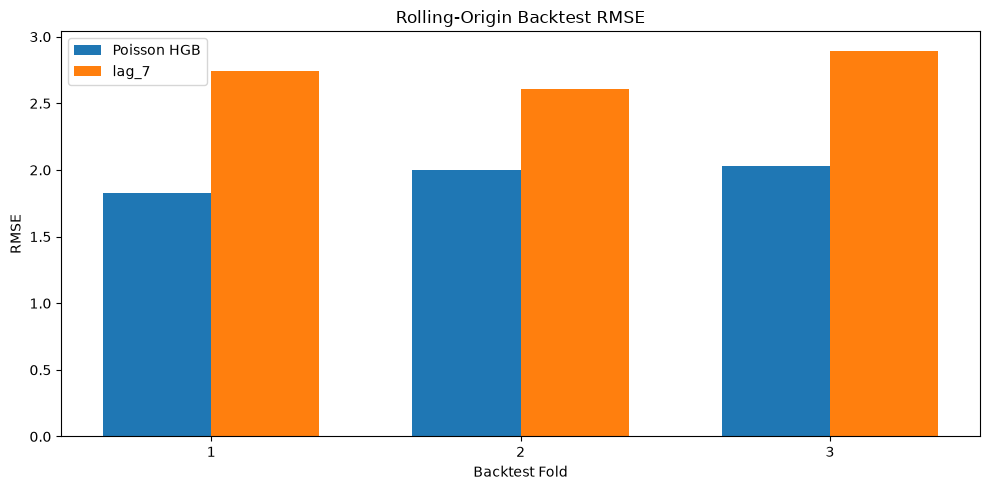

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(
    len(backtest_results_df)
)

width = 0.35

ax.bar(
    x - width / 2,
    backtest_results_df["model_RMSE"],
    width,
    label="Poisson HGB",
)

ax.bar(
    x + width / 2,
    backtest_results_df["lag7_RMSE"],
    width,
    label="lag_7",
)

ax.set_title(
    "Rolling-Origin Backtest RMSE"
)
ax.set_xlabel("Backtest Fold")
ax.set_ylabel("RMSE")
ax.set_xticks(
    x,
    backtest_results_df["fold"],
)
ax.legend()

plt.tight_layout()
plt.show()

In [26]:
backtest_results_df.to_csv(
    BACKTEST_RESULTS_FILE,
    index=False,
)

print(
    "Saved:",
    BACKTEST_RESULTS_FILE,
)

Saved: ..\outputs\evaluation\rolling_backtest_results.csv


# Production Forecasting Readiness

## 19. Strict 28-Day Forecasting Limitation

The current development model is valid for a **daily-updated** workflow:

- predict today's demand
- observe today's actual sales
- update lag/rolling features
- predict the next day

However, a true 28-day forecast made entirely on day 0 cannot use actual sales from days 1–27 of that future horizon.

For example:

- horizon day 1 can safely use `lag_1`
- horizon day 8 cannot use the *actual* `lag_7` value if that lag falls inside the unknown future horizon
- rolling means for later horizon days would also require future sales unless they are recursively updated using earlier model predictions

Therefore, before deployment, the forecasting service must use one of these strategies:

1. **Recursive forecasting** — predict day 1, feed that prediction into future lag/rolling calculations, then predict day 2, and continue through day 28.
2. **Horizon-specific/direct models** — train separate logic for each forecast horizon.
3. **Only origin-safe features** — use features guaranteed to be known at the forecast origin.

Notebook 06 dynamic pricing should not assume the current precomputed test features are a strict 28-day production forecast.

## 20. Model Acceptance Criteria

For this development stage, the forecasting model is considered strong enough to continue if:

- it beats `lag_7` RMSE on the final test set
- it beats `lag_7` in every rolling-origin backtest fold
- average backtest RMSE improvement over `lag_7` is positive
- absolute aggregate bias is reasonably small
- no major data leakage is discovered
- weaknesses are documented before pricing simulation

These checks evaluate whether the model adds forecasting value. They do **not** claim the model is production-ready.

In [27]:
test_beats_lag7 = (
    ml_row["RMSE"]
    < lag7_row["RMSE"]
)

backtest_beats_lag7_all = (
    backtest_results_df[
        "model_RMSE"
    ]
    < backtest_results_df[
        "lag7_RMSE"
    ]
).all()

positive_average_backtest_improvement = (
    backtest_results_df[
        "rmse_improvement_vs_lag7"
    ].mean()
    > 0
)

small_aggregate_bias = (
    abs(bias_pct)
    < 0.10
)

acceptance_checks = pd.DataFrame(
    {
        "check": [
            "Test RMSE beats lag_7",
            "All backtest folds beat lag_7",
            "Average backtest improvement is positive",
            "Absolute aggregate bias < 10%",
        ],
        "passed": [
            test_beats_lag7,
            backtest_beats_lag7_all,
            positive_average_backtest_improvement,
            small_aggregate_bias,
        ],
    }
)

acceptance_checks

,check,passed
0,Test RMSE beats lag_7,True
1,All backtest folds beat lag_7,True
2,Average backtest improvement is positive,True
3,Absolute aggregate bias < 10%,True


In [28]:
development_model_accepted = (
    acceptance_checks["passed"].all()
)

print(
    "Development model accepted:",
    development_model_accepted,
)

Development model accepted: True


## 21. Evaluation Findings

### Final Test vs. Baselines

- Selected-model RMSE: **2.206**
- `lag_7` RMSE: **2.924**
- RMSE improvement: **24.54%**
- Selected-model MAE: **1.252**
- `lag_7` MAE: **1.630**
- MAE improvement: **23.17%**

### Bias

- Mean residual: **-0.018**
- Total actual demand: **8,684 units**
- Total predicted demand: **8,784.85 units**
- Aggregate bias: **+1.16%**
- The model slightly overpredicts overall demand, but aggregate bias is small.

### Intermittent Demand

- Zero-demand rows: **2,543**
- MAE on zero-demand rows: **0.950**
- Average prediction when actual demand is zero: **0.950 units**
- Share of zero-demand rows predicted above 1 unit: **35.43%**
- MAE on positive-demand rows: **1.503**

### Product / Demand Segments

- Low-demand MAE: **0.715**
- Medium-demand MAE: **1.116**
- High-demand MAE: **1.942**
- Forecasting error increases as product demand becomes larger and more volatile.
- The largest individual misses are concentrated in unusual demand spikes, which remain a weakness of the current model.

### Backtesting

- Average model RMSE: **1.953**
- Average `lag_7` RMSE: **2.748**
- Average RMSE improvement: **28.82%**
- Worst-fold RMSE improvement: **23.40%**
- The model beat the `lag_7` baseline in **all 3 rolling-origin backtest folds**.

### Final Decision

- The development model **passed all current acceptance checks**.
- It consistently improves on the weekly naive baseline on both the final test period and the historical backtest windows.
- Remaining weaknesses are intermittent zero-demand behavior and large unexpected demand spikes.
- The current evaluation represents a **daily-updated forecasting workflow**, not yet a strict one-shot 28-day production forecast.
- A production multi-step forecast will require recursive forecasting, horizon-specific models, or features guaranteed to be known at the forecast origin.
- The model is strong enough to continue into the dynamic-pricing stage.


## 22. Next Step

The development model passed all current acceptance checks, so the project can proceed to:

`06_dynamic_pricing.ipynb`

Notebook 06 will begin the pricing layer by:

- defining candidate prices
- using demand predictions as the demand baseline
- modeling how demand may respond to price changes
- estimating revenue under candidate prices
- applying pricing constraints
- recommending a price
- comparing recommended price vs. current price

### Important

A demand forecast alone does **not** tell us how demand changes when price changes.

Therefore the pricing notebook must treat price elasticity / price-response modeling as a separate problem rather than simply changing `sell_price` and assuming the demand model has learned a causal price effect.

The current forecasting model also represents a **daily-updated** workflow. Before production deployment, the forecasting service will need a strict multi-step strategy such as recursive forecasting, horizon-specific models, or origin-safe features.

After Notebook 06, the main notebook phase is complete and the project moves into:

- reusable Python feature, forecasting, and pricing modules
- FastAPI
- Streamlit
- Airflow orchestration
- Docker integration
- deployment
- final testing and documentation
